In [ ]:
!pip install tensorflow matplotlib numpy

In [ ]:
!pip install -q kaggle

In [ ]:
import json

kaggle_dict = {
    "username": "****",
    "key": "****"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install -q kaggle
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:03<00:00, 187MB/s]



In [ ]:
!unzip plantdisease.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: /content/dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: /content/dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: /content/dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: /content/dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: /content/dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
 

In [ ]:
import os
os.listdir('/content/dataset')

['plantvillage', 'PlantVillage']

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train = datagen.flow_from_directory(
    '/content/dataset/PlantVillage',
    target_size=(224,224),
    batch_size=32,
    subset='training'
)

val = datagen.flow_from_directory(
    '/content/dataset/PlantVillage',
    target_size=(224,224),
    batch_size=32,
    subset='validation'
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False   # important (fast training)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
import time

start = time.time()

history = model.fit(
    train,
    validation_data=val,
    epochs=5
)

end = time.time()

print("Training time:", end-start)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 81s 122ms/step - accuracy: 0.8251 - loss: 0.5566 - val_accuracy: 0.8918 - val_loss: 0.3252
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 33s 63ms/step - accuracy: 0.9106 - loss: 0.2692 - val_accuracy: 0.8979 - val_loss: 0.3096
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 32s 61ms/step - accuracy: 0.9319 - loss: 0.1995 - val_accuracy: 0.9047 - val_loss: 0.2876
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - accuracy: 0.9507 - loss: 0.1517 - val_accuracy: 0.9241 - val_loss: 0.2262
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - accuracy: 0.9589 - loss: 0.1218 - val_accuracy: 0.9124 - val_loss: 0.2557
Training time: 212.78764843940735


In [ ]:
import os
import random

base_path = '/content/dataset/PlantVillage'

class_name = random.choice(os.listdir(base_path))
class_path = os.path.join(base_path, class_name)

img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

print("Testing image path:", img_path)

Testing image path: /content/dataset/PlantVillage/Pepper__bell___healthy/90b246e8-9cf6-440f-a867-3c32a697f284___JR_HL 8041.JPG


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

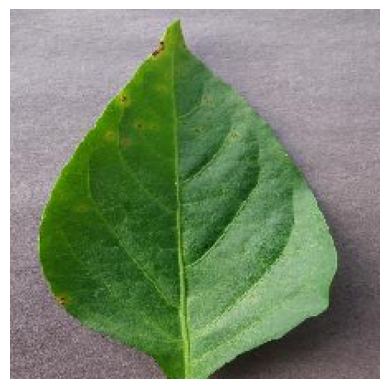

In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.axis('off')

In [ ]:
import numpy as np

img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

class_names = list(train.class_indices.keys())

pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


In [ ]:
print("Crop Health Analysis Result:\n")

print("Disease Detected:", pred_class)
print("Confidence Score:", round(confidence*100,2), "%\n")

treatment = {
    "Tomato___Early_blight": "Use fungicide, remove infected leaves",
    "Tomato___Late_blight": "Apply copper fungicide, avoid overwatering",
    "Potato___Early_blight": "Use mancozeb spray",
    "Potato___Late_blight": "Improve drainage, apply fungicide",
    "Healthy": "No treatment needed"
}

print("Recommended Treatment:")
print(treatment.get(pred_class, "Consult agricultural expert"))

Crop Health Analysis Result:

Disease Detected: Pepper__bell___healthy
Confidence Score: 96.47 %

Recommended Treatment:
Consult agricultural expert


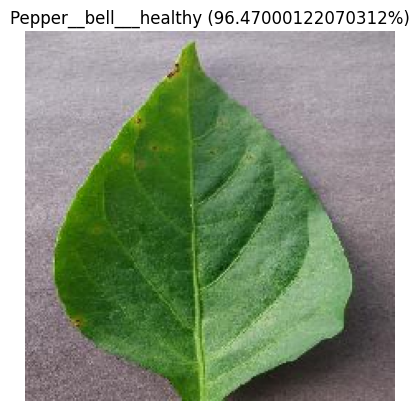

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis('off')

plt.title(f"{pred_class} ({round(confidence*100,2)}%)")
plt.show()

In [ ]:
import os
import random

base_path = '/content/dataset/PlantVillage'

# koi bhi random class select karo
class_name = random.choice(os.listdir(base_path))
class_path = os.path.join(base_path, class_name)

# random image pick karo
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

print("Testing image path:", img_path)

Testing image path: /content/dataset/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/4a339e6d-1ba7-4180-86a5-c9682ec87516___UF.GRC_YLCV_Lab 01835.JPG


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

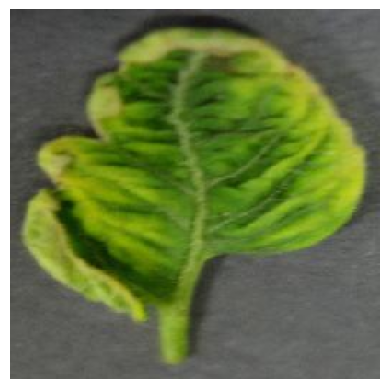

In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.axis('off')

In [ ]:
import numpy as np

img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

class_names = list(train.class_indices.keys())

pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [ ]:
print("Crop Health Analysis Result:\n")

print("Disease Detected:", pred_class)
print("Confidence Score:", round(confidence*100,2), "%\n")

treatment = {
    "Tomato___Early_blight": "Use fungicide, remove infected leaves",
    "Tomato___Late_blight": "Apply copper fungicide, avoid overwatering",
    "Potato___Early_blight": "Use mancozeb spray",
    "Potato___Late_blight": "Improve drainage, apply fungicide",
    "Healthy": "No treatment needed"
}

print("Recommended Treatment:")
print(treatment.get(pred_class, "Consult agricultural expert"))

Crop Health Analysis Result:

Disease Detected: Tomato__Tomato_YellowLeaf__Curl_Virus
Confidence Score: 100.0 %

Recommended Treatment:
Consult agricultural expert


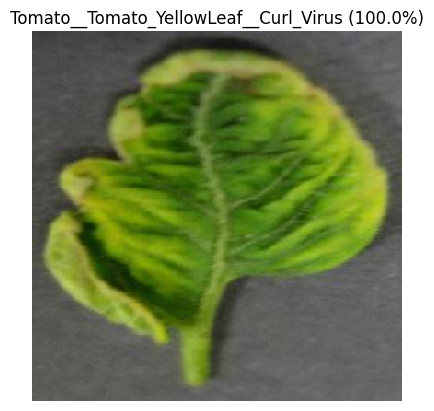

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis('off')

plt.title(f"{pred_class} ({round(confidence*100,2)}%)")
plt.show()

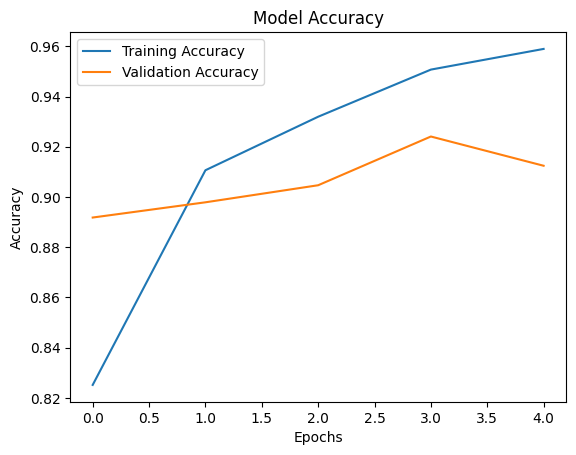

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.legend()
plt.show()

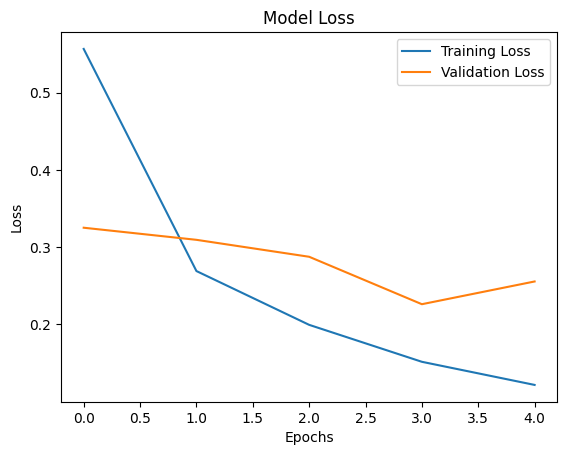

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.legend()
plt.show()

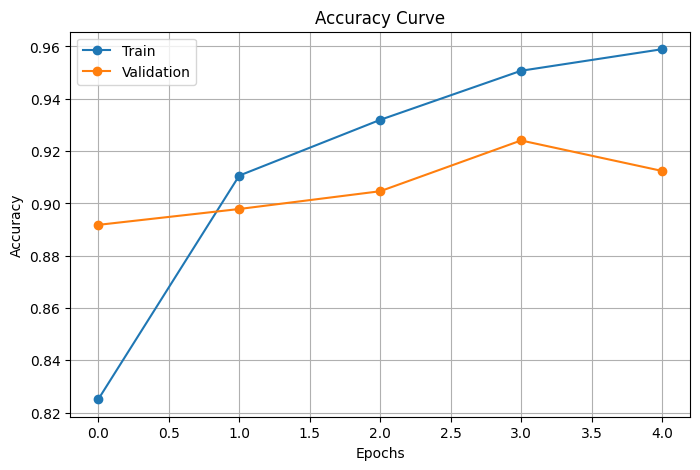

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid()
plt.show()

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 130.8 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


model = tf.keras.models.load_model('model.h5')

class_names = ['Tomato___Early_blight','Potato___Early_blight','Healthy']

treatment = {
    "Tomato___Early_blight": "Use fungicide, remove infected leaves",
    "Potato___Early_blight": "Use mancozeb spray",
    "Healthy": "No treatment needed"
}

st.title("🌿 Smart Crop Health Monitoring")

uploaded_file = st.file_uploader("Upload a leaf image", type=["jpg","png"])

if uploaded_file is not None:
    img = image.load_img(uploaded_file, target_size=(224,224))
    st.image(img, caption="Uploaded Image")

    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    pred_class = class_names[np.argmax(pred)]
    confidence = float(np.max(pred))

    st.subheader("Result")
    st.write("Disease:", pred_class)
    st.write("Confidence:", round(confidence*100,2), "%")
    st.write("Treatment:", treatment.get(pred_class, "Consult expert"))

Writing app.py


In [ ]:
model.save("model.h5")

In [ ]:
!pip install pyngrok

In [ ]:
!ngrok config add-authtoken 3DJTXg0ZxZVsVYJD9azzuRIMurE_7ZvNWtV71zUKzy7HQWEso

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok
get_ipython().system_raw('streamlit run app.py &')

public_url = ngrok.connect(addr='8501')
print(public_url)

NgrokTunnel: "https://refusal-marmalade-bouncing.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!pip uninstall -y tensorflow tensorflow-intel

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
Traceback (most recent call last):
  File "/usr/lib/python3.12/shutil.py", line 847, in move
    os.rename(src, real_dst)
OSError: [Errno 18] Invalid cross-device link: '/usr/local/lib/python3.12/dist-packages/tensorflow/' -> '/usr/local/lib/python3.12/dist-packages/~ensorflow'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/uninstall.py", line 106, in run
    uninstall_pathset = req.uninstall(
                        ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/req/req_install.py", line 722, in uninstall
    uninstalled_pathset.remove(auto_confirm, verbose)
  File "/usr/local/li

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model2 = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model2.trainable = False

model2 = models.Sequential([
    base_model2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train.num_classes, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
import time

start = time.time()

history2 = model2.fit(
    train,
    validation_data=val,
    epochs=5
)

end = time.time()

resnet_time = end - start

print("ResNet50 Training Time:", resnet_time)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 85s 143ms/step - accuracy: 0.2358 - loss: 2.3356 - val_accuracy: 0.3372 - val_loss: 2.1318
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 62s 120ms/step - accuracy: 0.3554 - loss: 1.9881 - val_accuracy: 0.3976 - val_loss: 1.8775
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 61s 117ms/step - accuracy: 0.4161 - loss: 1.7815 - val_accuracy: 0.4379 - val_loss: 1.6897
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 61s 117ms/step - accuracy: 0.4631 - loss: 1.6418 - val_accuracy: 0.4597 - val_loss: 1.5991
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 61s 117ms/step - accuracy: 0.4946 - loss: 1.5464 - val_accuracy: 0.5180 - val_loss: 1.5053
ResNet50 Training Time: 328.66459941864014


In [ ]:
import os
import random

base_path = '/content/dataset/PlantVillage'

class_name = random.choice(os.listdir(base_path))
class_path = os.path.join(base_path, class_name)

img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

print("Testing image path:", img_path)

Testing image path: /content/dataset/PlantVillage/Potato___Late_blight/4f249e3b-92a0-43e5-a70d-fe3045630437___RS_LB 3913.JPG


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

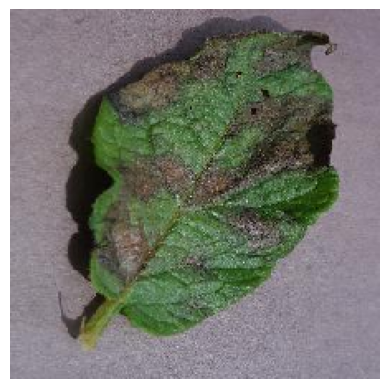

In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.axis('off')

In [ ]:
print("Crop Health Analysis Result:\n")

print("Disease Detected:", pred_class)
print("Confidence Score:", round(confidence*100,2), "%\n")

treatment = {
    "Tomato___Early_blight": "Use fungicide, remove infected leaves",
    "Tomato___Late_blight": "Apply copper fungicide, avoid overwatering",
    "Potato___Early_blight": "Use mancozeb spray",
    "Potato___Late_blight": "Improve drainage, apply fungicide",
    "Healthy": "No treatment needed"
}

print("Recommended Treatment:")
print(treatment.get(pred_class, "Consult agricultural expert"))

Crop Health Analysis Result:

Disease Detected: Tomato__Tomato_YellowLeaf__Curl_Virus
Confidence Score: 100.0 %

Recommended Treatment:
Consult agricultural expert


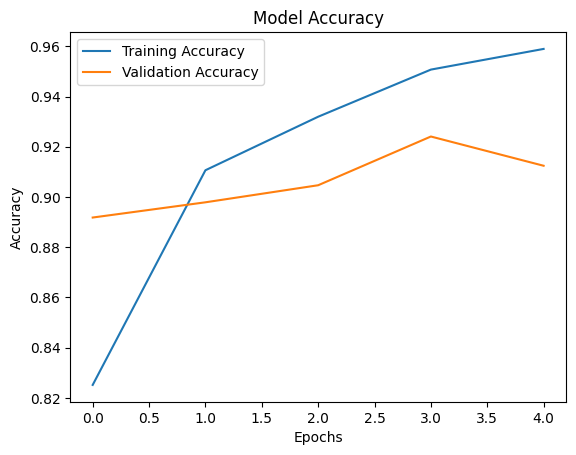

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.legend()
plt.show()

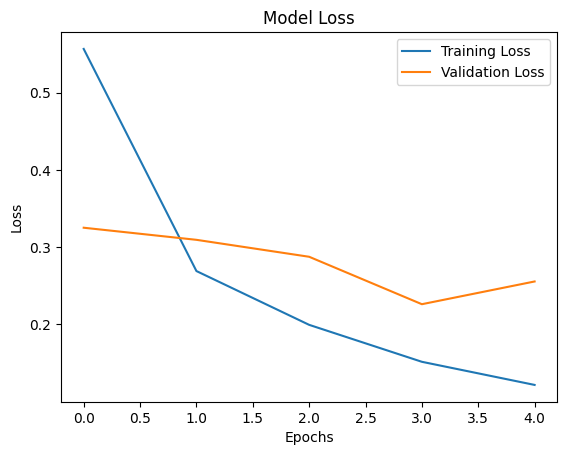

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.legend()
plt.show()

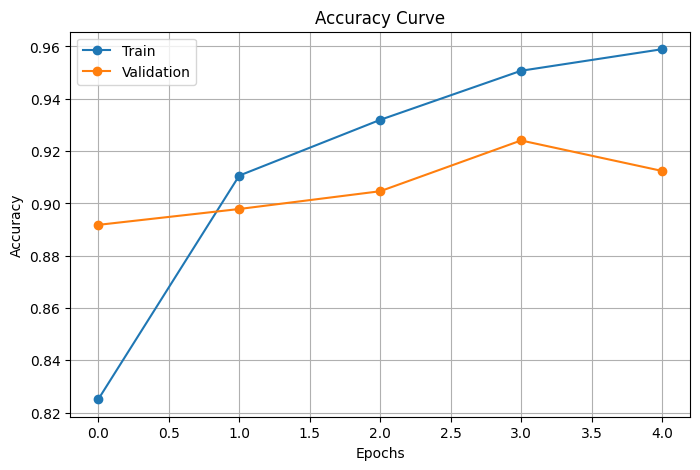

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid()
plt.show()

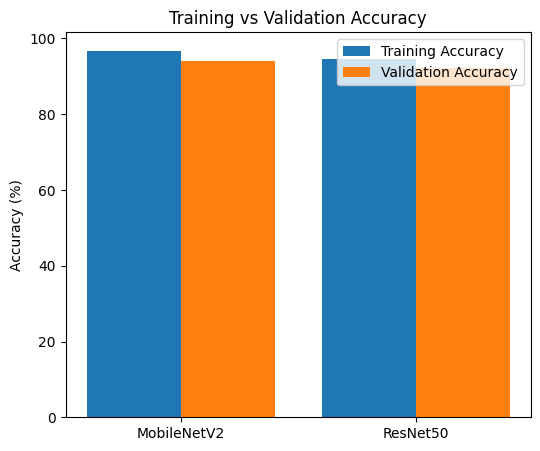

In [1]:
import matplotlib.pyplot as plt

models = ['MobileNetV2', 'ResNet50']

train_acc = [96.8, 94.6]
val_acc = [94.1, 92.1]

plt.figure(figsize=(6,5))

x = range(len(models))

plt.bar(x, train_acc, width=0.4, label='Training Accuracy')
plt.bar([i + 0.4 for i in x], val_acc, width=0.4, label='Validation Accuracy')

plt.xticks([i + 0.2 for i in x], models)

plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

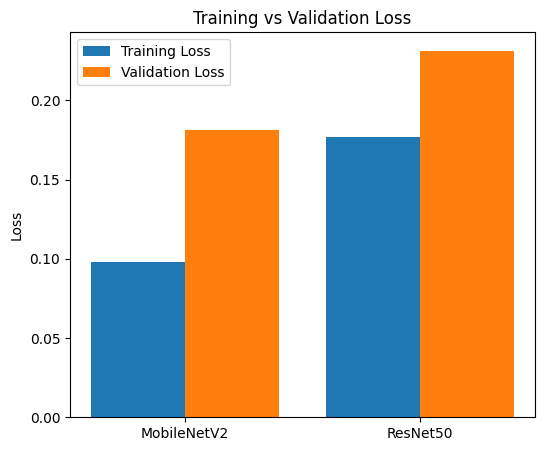

In [3]:
import matplotlib.pyplot as plt

models = ['MobileNetV2', 'ResNet50']

train_loss = [0.0982, 0.1768]
val_loss = [0.1815, 0.2314]

plt.figure(figsize=(6,5))

x = range(len(models))

plt.bar(x, train_loss, width=0.4, label='Training Loss')
plt.bar([i + 0.4 for i in x], val_loss, width=0.4, label='Validation Loss')

plt.xticks([i + 0.2 for i in x], models)

plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

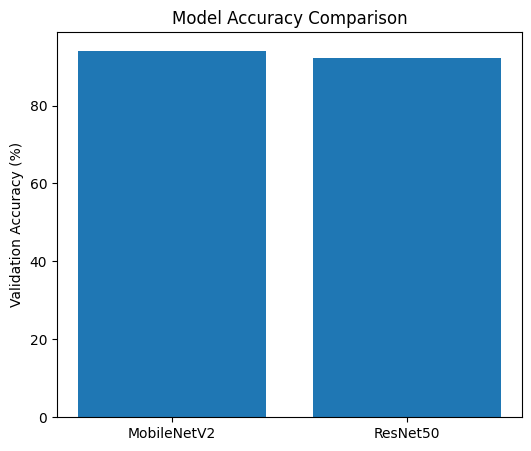

In [4]:
import matplotlib.pyplot as plt

models = ['MobileNetV2', 'ResNet50']
accuracy = [94.1, 92.1]

plt.figure(figsize=(6,5))

plt.bar(models, accuracy)

plt.ylabel('Validation Accuracy (%)')
plt.title('Model Accuracy Comparison')

plt.show()

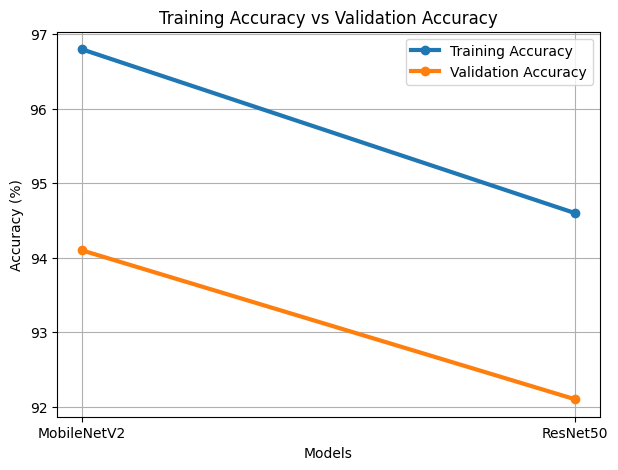

In [5]:
import matplotlib.pyplot as plt

models = ['MobileNetV2', 'ResNet50']

train_acc = [96.8, 94.6]
val_acc = [94.1, 92.1]

plt.figure(figsize=(7,5))

plt.plot(models, train_acc, marker='o', linewidth=3, label='Training Accuracy')
plt.plot(models, val_acc, marker='o', linewidth=3, label='Validation Accuracy')

plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy vs Validation Accuracy')
plt.legend()

plt.grid(True)

plt.show()

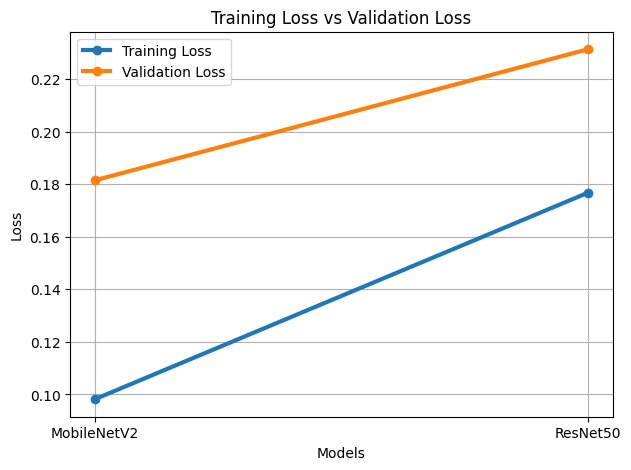

In [6]:
import matplotlib.pyplot as plt

models = ['MobileNetV2', 'ResNet50']

train_loss = [0.0982, 0.1768]
val_loss = [0.1815, 0.2314]

plt.figure(figsize=(7,5))

plt.plot(models, train_loss, marker='o', linewidth=3, label='Training Loss')
plt.plot(models, val_loss, marker='o', linewidth=3, label='Validation Loss')

plt.xlabel('Models')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()

plt.grid(True)

plt.show()

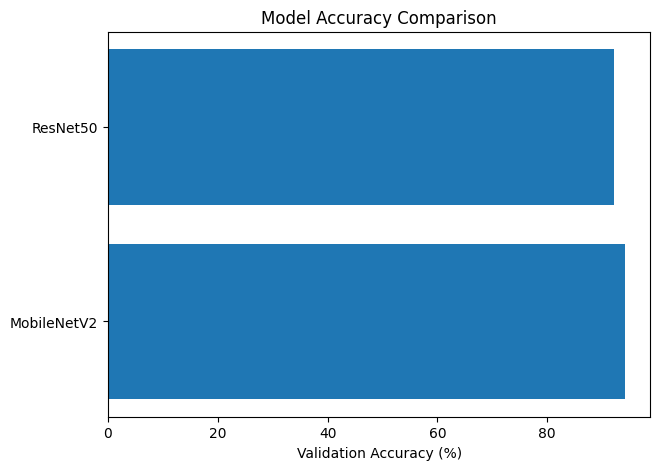

In [8]:
import matplotlib.pyplot as plt

models = ['MobileNetV2', 'ResNet50']
accuracy = [94.1, 92.1]

plt.figure(figsize=(7,5))

plt.barh(models, accuracy)

plt.xlabel('Validation Accuracy (%)')
plt.title('Model Accuracy Comparison')

plt.show()

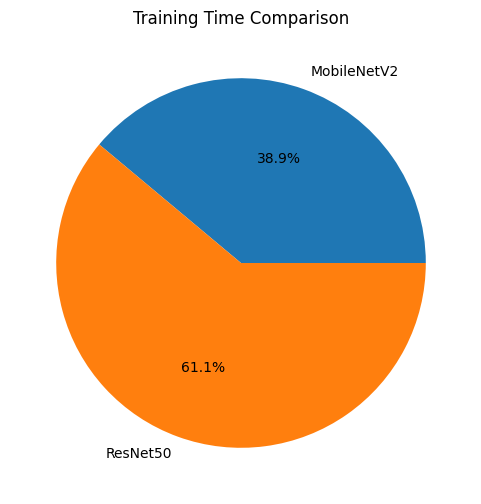

In [9]:
import matplotlib.pyplot as plt

labels = ['MobileNetV2', 'ResNet50']
times = [158, 248]

plt.figure(figsize=(6,6))

plt.pie(times, labels=labels, autopct='%1.1f%%')

plt.title('Training Time Comparison')

plt.show()

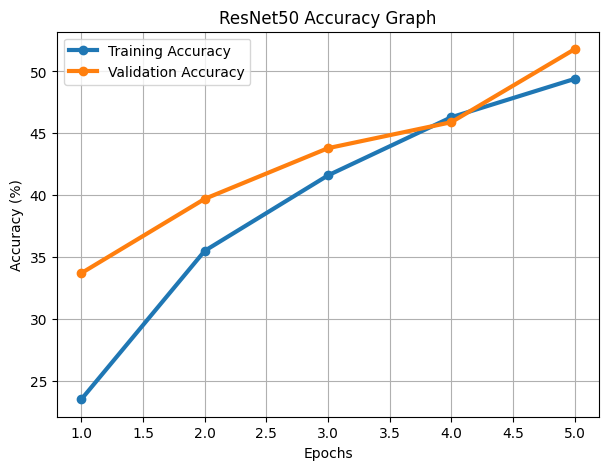

In [10]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]

train_acc = [23.5, 35.5, 41.6, 46.3, 49.4]
val_acc = [33.7, 39.7, 43.8, 45.9, 51.8]

plt.figure(figsize=(7,5))

plt.plot(epochs, train_acc, marker='o', linewidth=3, label='Training Accuracy')
plt.plot(epochs, val_acc, marker='o', linewidth=3, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('ResNet50 Accuracy Graph')
plt.legend()

plt.grid(True)

plt.show()

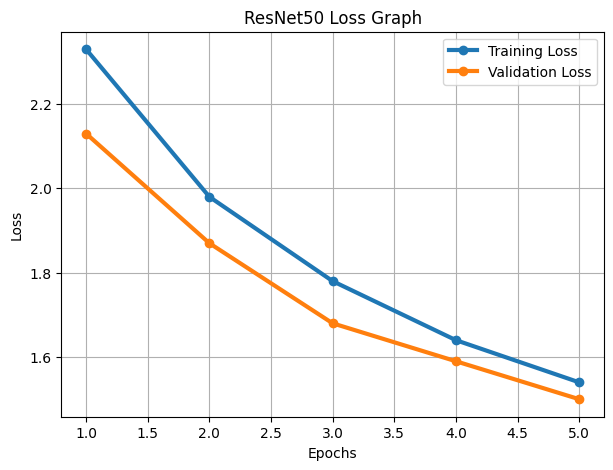

In [11]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]

train_loss = [2.33, 1.98, 1.78, 1.64, 1.54]
val_loss = [2.13, 1.87, 1.68, 1.59, 1.50]

plt.figure(figsize=(7,5))

plt.plot(epochs, train_loss, marker='o', linewidth=3, label='Training Loss')
plt.plot(epochs, val_loss, marker='o', linewidth=3, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet50 Loss Graph')
plt.legend()

plt.grid(True)

plt.show()